# Campaña de Marketing Bancario

Este notebook desarrolla un analisis exploratorio completo del dataset de marketing bancario y construye un modelo de regresion logistica para predecir si un cliente contratara un deposito a largo plazo.

## Objetivo de negocio

El banco quiere enfocar sus llamadas comerciales en los clientes con mayor probabilidad de contratar un deposito a largo plazo. Para ello se construye un clasificador que ayude a priorizar clientes y reducir tiempo y coste en contactos con baja probabilidad de conversion.

In [1]:
from io import StringIO
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

CURRENT_DIR = Path.cwd().resolve()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "src" else CURRENT_DIR
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from app import (
    PROCESSED_DIR,
    TARGET_COLUMN,
    build_model_pipeline,
    clean_bank_data,
    evaluate_model,
    load_dataset,
    optimize_model,
    prepare_feature_target,
    prepare_modeling_data,
    save_processed_data,
    split_data,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="crest")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
df = load_dataset()
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


In [3]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())
print(f"Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas")
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"41,188.00",NaN,NaN,NaN,40.02,10.42,17.00,32.00,38.00,47.00,98.00
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing_summary = df.isna().sum().to_frame("missing_values")
unknown_summary = (df == "unknown").sum().to_frame("unknown_values")
quality_summary = missing_summary.join(unknown_summary)
quality_summary = quality_summary[(quality_summary["missing_values"] > 0) | (quality_summary["unknown_values"] > 0)]
print(f"Duplicados detectados: {df.duplicated().sum()}")
quality_summary.sort_values("unknown_values", ascending=False)

Duplicados detectados: 12


,missing_values,unknown_values
default,0,8597
education,0,1731
housing,0,990
loan,0,990
job,0,330
marital,0,80


,percentage
y,
no,88.73
yes,11.27


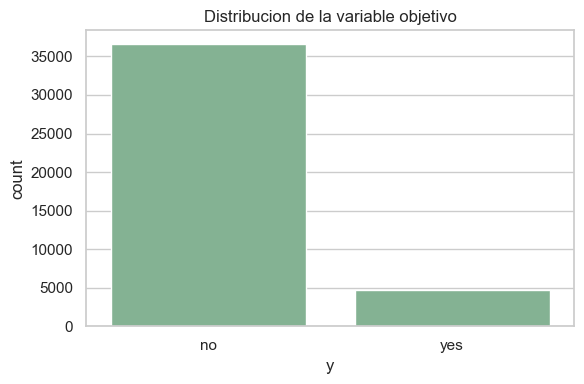

In [5]:
target_distribution = df[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2).rename_axis(TARGET_COLUMN).to_frame("percentage")
display(target_distribution)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index)
plt.title("Distribucion de la variable objetivo")
plt.tight_layout()

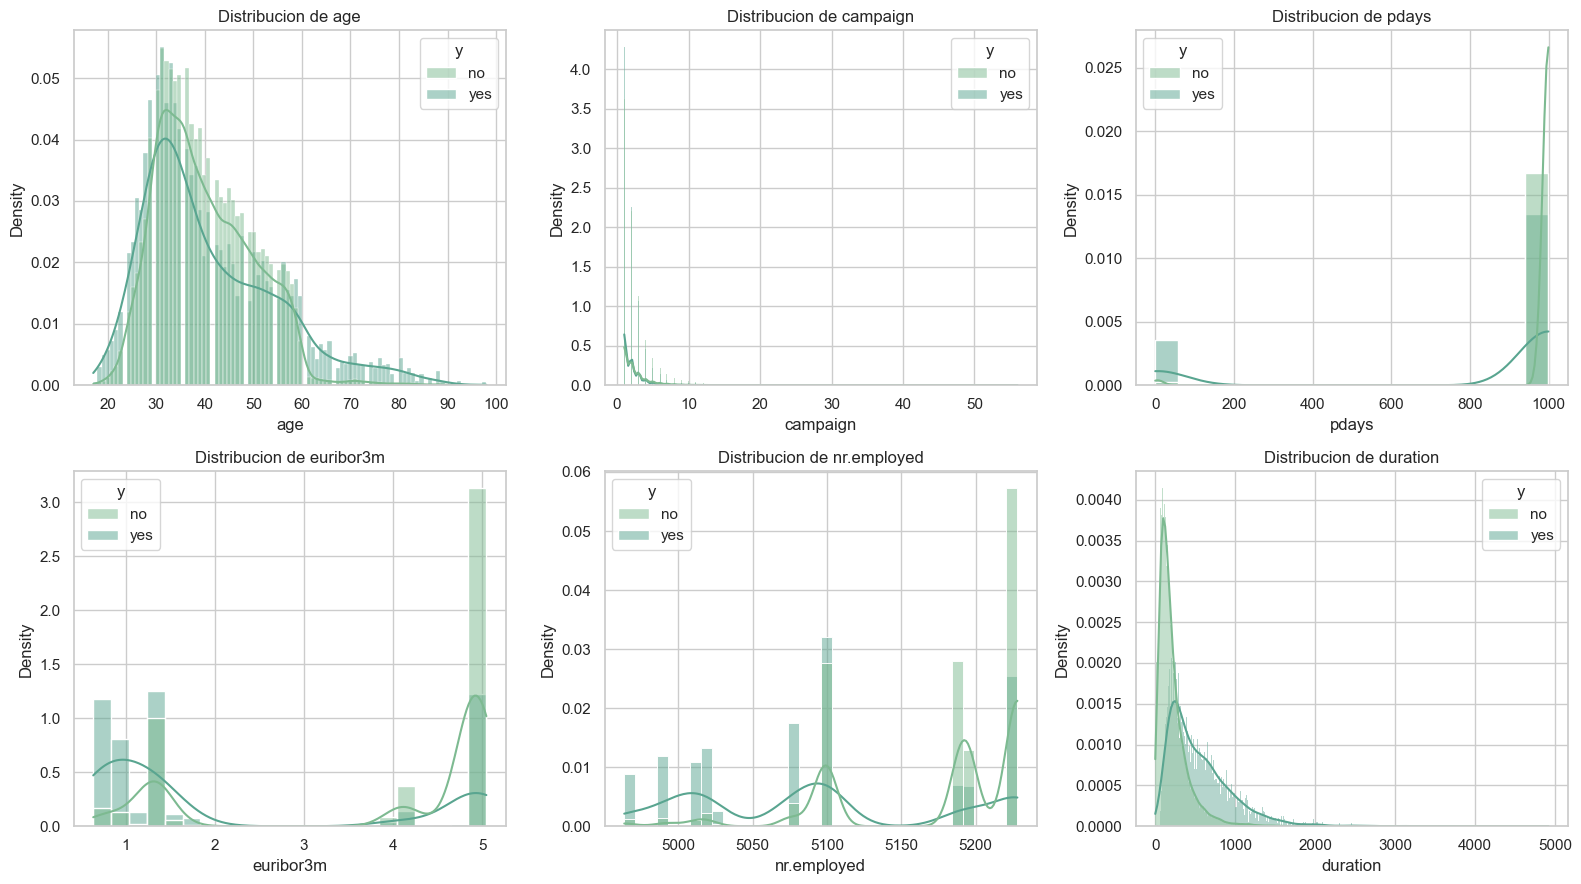

In [6]:
numeric_columns = ["age", "campaign", "pdays", "euribor3m", "nr.employed", "duration"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(data=df, x=column, hue=TARGET_COLUMN, kde=True, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribucion de {column}")
plt.tight_layout()

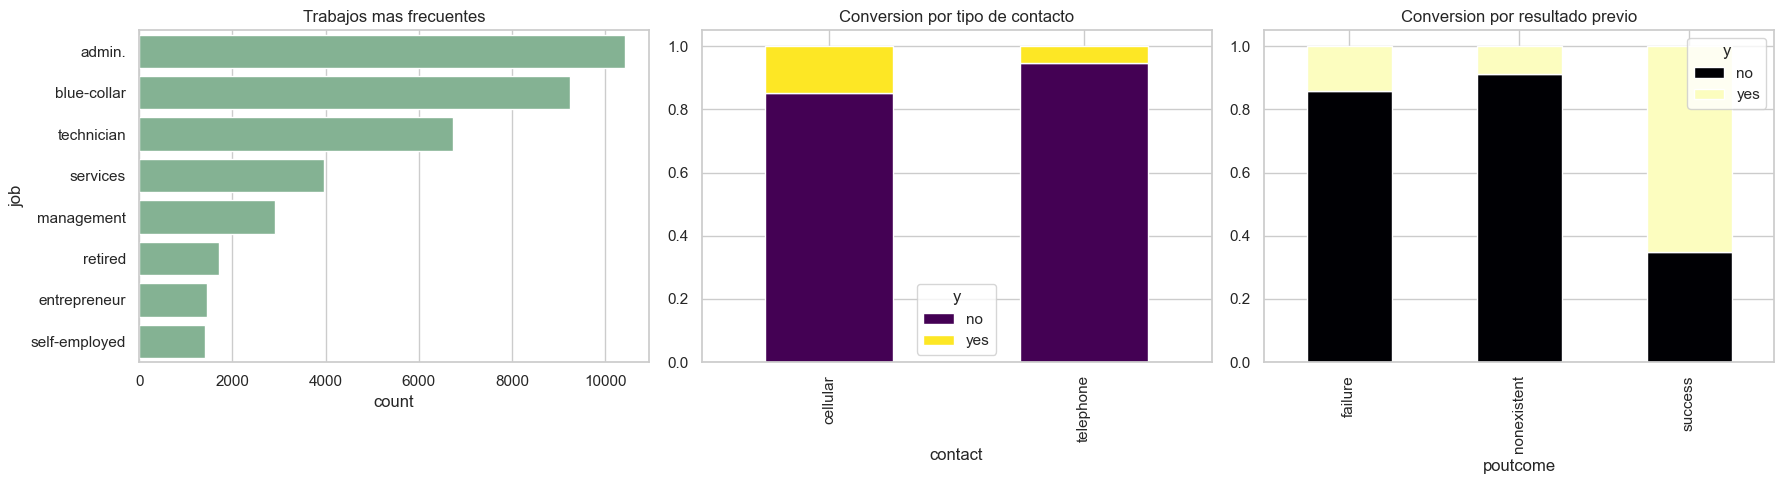

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, y="job", order=df["job"].value_counts().index[:8], ax=axes[0])
axes[0].set_title("Trabajos mas frecuentes")

subscription_by_contact = pd.crosstab(df["contact"], df[TARGET_COLUMN], normalize="index")
subscription_by_contact.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Conversion por tipo de contacto")
axes[1].legend(title=TARGET_COLUMN)

subscription_by_poutcome = pd.crosstab(df["poutcome"], df[TARGET_COLUMN], normalize="index")
subscription_by_poutcome.plot(kind="bar", stacked=True, ax=axes[2], colormap="magma")
axes[2].set_title("Conversion por resultado previo")
axes[2].legend(title=TARGET_COLUMN)
plt.tight_layout()

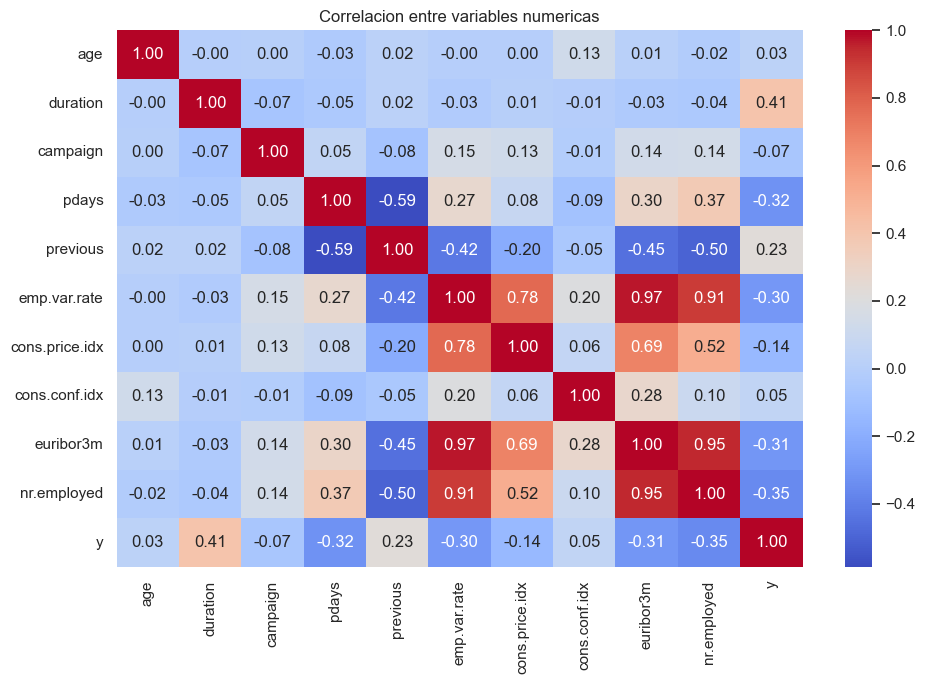

In [8]:
corr_df = df.select_dtypes(include="number").copy()
corr_df[TARGET_COLUMN] = df[TARGET_COLUMN].map({"no": 0, "yes": 1})
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlacion entre variables numericas")
plt.tight_layout()

## Limpieza y preparacion de datos

Durante la preparacion del dataset se tomaron estas decisiones:

- Se reemplazaron los valores `unknown` por nulos para tratarlos de forma consistente en el pipeline.
- Se eliminaron filas duplicadas.
- Se descarto `duration` para modelar, porque solo se conoce despues de la llamada y genera fuga de informacion.
- Se mantuvo la variable objetivo `y` y se dividio el dataset en train y test con estratificacion para respetar el desbalance original.
- Las variables numericas se imputan con la mediana y se escalan; las categoricas se imputan con la moda y se codifican con one-hot encoding.

In [9]:
clean_df = clean_bank_data(df)
modeling_df = prepare_modeling_data(clean_df)
train_df, test_df = split_data(modeling_df)

print(f"Dataset limpio: {clean_df.shape}")
print(f"Dataset para modelado: {modeling_df.shape}")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

save_processed_data(modeling_df, train_df, test_df, pd.DataFrame())
display(modeling_df.head())

Dataset limpio: (41176, 21)
Dataset para modelado: (41176, 20)
Train: (32940, 20)
Test: (8236, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


In [10]:
X_train, y_train = prepare_feature_target(train_df)
X_test, y_test = prepare_feature_target(test_df)

baseline_model = build_model_pipeline(X_train)
baseline_model.fit(X_train, y_train)
baseline_metrics = evaluate_model(baseline_model, X_test, y_test)
pd.DataFrame([{"model": "baseline_logistic_regression", **baseline_metrics}])

,model,accuracy,precision,recall,f1,roc_auc
0,baseline_logistic_regression,0.90,0.65,0.21,0.32,0.80


In [11]:
search = optimize_model(X_train, y_train)
optimized_model = search.best_estimator_
optimized_metrics = evaluate_model(optimized_model, X_test, y_test)
comparison_df = pd.DataFrame([
    {"model": "baseline_logistic_regression", **baseline_metrics},
    {"model": "optimized_logistic_regression", **optimized_metrics},
])

save_processed_data(modeling_df, train_df, test_df, comparison_df)
print(f"Mejores hiperparametros: {search.best_params_}")
comparison_df

Mejores hiperparametros: {'model__C': 3.0, 'model__class_weight': 'balanced'}


,model,accuracy,precision,recall,f1,roc_auc
0,baseline_logistic_regression,0.90,0.65,0.21,0.32,0.80
1,optimized_logistic_regression,0.83,0.36,0.64,0.46,0.80


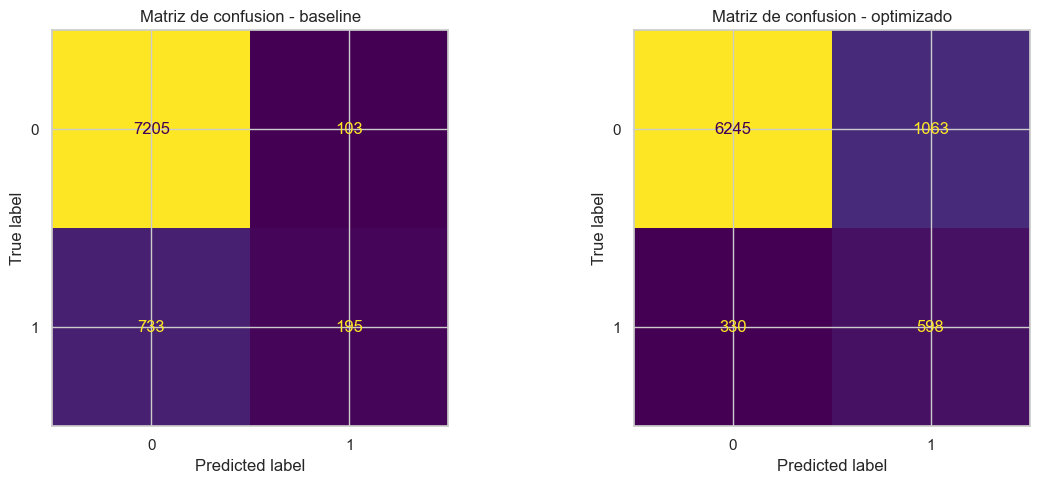

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test, ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusion - baseline")
ConfusionMatrixDisplay.from_estimator(optimized_model, X_test, y_test, ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de confusion - optimizado")
plt.tight_layout()

In [13]:
feature_names = optimized_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = optimized_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df.sort_values("abs_coefficient", ascending=False).head(10).drop(columns="abs_coefficient")

,feature,coefficient
4,num__emp.var.rate,-2.28
43,cat__month_mar,1.30
5,num__cons.price.idx,1.14
42,cat__month_jun,-0.82
44,cat__month_may,-0.65
45,cat__month_nov,-0.56
39,cat__month_aug,0.46
40,cat__month_dec,0.44
8,num__nr.employed,0.41
7,num__euribor3m,0.39


## Conclusiones

- El dataset esta desbalanceado: la clase positiva representa una proporcion pequena de clientes, por lo que accuracy por si sola no es suficiente.
- `duration` parecia muy predictiva, pero se excluyo por fuga de informacion y para mantener un caso de uso realista.
- El modelo base logra buena accuracy, pero su recall para clientes que si suscriben es bajo.
- La optimizacion con `class_weight=balanced` mejora el recall y el F1-score, lo que resulta mas util para una campana de marketing que busca identificar potenciales suscriptores.
- El modelo optimizado es una mejor base operativa para priorizar llamadas comerciales, aunque todavia puede mejorarse con ingenieria de variables o modelos mas robustos.